In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler


from sklearn.utils.class_weight import compute_class_weight
import joblib


# Reading

In [2]:
data = pd.read_json("News_Category_Dataset_v3.json", lines=True)
data

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22
...,...,...,...,...,...,...
209522,https://www.huffingtonpost.com/entry/rim-ceo-t...,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,TECH,Verizon Wireless and AT&T are already promotin...,"Reuters, Reuters",2012-01-28
209523,https://www.huffingtonpost.com/entry/maria-sha...,Maria Sharapova Stunned By Victoria Azarenka I...,SPORTS,"Afterward, Azarenka, more effusive with the pr...",,2012-01-28
209524,https://www.huffingtonpost.com/entry/super-bow...,"Giants Over Patriots, Jets Over Colts Among M...",SPORTS,"Leading up to Super Bowl XLVI, the most talked...",,2012-01-28
209525,https://www.huffingtonpost.com/entry/aldon-smi...,Aldon Smith Arrested: 49ers Linebacker Busted ...,SPORTS,CORRECTION: An earlier version of this story i...,,2012-01-28


In [3]:
data.drop(['link','short_description','authors','date'],axis=1,inplace=True)

In [4]:
data

,headline,category
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY
3,The Funniest Tweets From Parents This Week (Se...,PARENTING
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS
...,...,...
209522,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,TECH
209523,Maria Sharapova Stunned By Victoria Azarenka I...,SPORTS
209524,"Giants Over Patriots, Jets Over Colts Among M...",SPORTS
209525,Aldon Smith Arrested: 49ers Linebacker Busted ...,SPORTS


# EDA

In [5]:
data['category'].value_counts()

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

In [6]:
def mapping_to_10(cat):
    if cat not in ["POLITICS","WELLNESS","ENTERTAINMENT","TRAVEL","STYLE & BEAUTY","QUEER VOICES","FOOD & DRINK","BUSINESS","SPORTS"]:
        return "OTHER"
    else:
        return cat

In [7]:
data['category_10']=data['category'].apply(mapping_to_10)

In [8]:
data

,headline,category,category_10
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,OTHER
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,OTHER
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,OTHER
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,OTHER
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,OTHER
...,...,...,...
209522,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,TECH,OTHER
209523,Maria Sharapova Stunned By Victoria Azarenka I...,SPORTS,SPORTS
209524,"Giants Over Patriots, Jets Over Colts Among M...",SPORTS,SPORTS
209525,Aldon Smith Arrested: 49ers Linebacker Busted ...,SPORTS,SPORTS


In [9]:
data['category_10'].value_counts()

category_10
OTHER             95148
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
SPORTS             5077
Name: count, dtype: int64

In [10]:
data['category'].value_counts().min()

1014

In [11]:
1014*33   #downsampling all categories inside the OTHER ,making it close to the 2nd max category (Other still balance)

33462

In [12]:
data['length'] = data['headline'].fillna('').str.split().apply(len)
data['length']

0         11
1         13
2         13
3          9
4         11
          ..
209522     8
209523    10
209524    16
209525     8
209526     9
Name: length, Length: 209527, dtype: int64

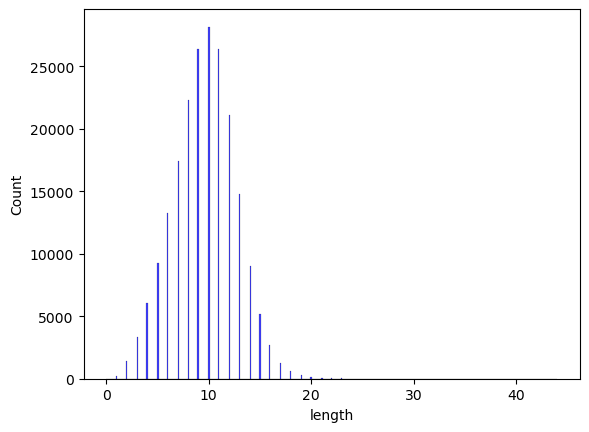

In [13]:
sns.histplot(data['length'],color='blue')
plt.show()

In [14]:
data['length'].describe()


count    209527.000000
mean          9.600744
std           3.068507
min           0.000000
25%           8.000000
50%          10.000000
75%          12.000000
max          44.000000
Name: length, dtype: float64

In [15]:
data['headline'].apply(len).sum()
#all words

12239594

In [16]:
unique=set()
for headline in data['headline']:
    unique.update(headline.lower().split())

In [17]:
len(unique)

120304

In [18]:
data[data['length']==0]

,headline,category,category_10,length
90944,,POLITICS,POLITICS,0
95567,,RELIGION,OTHER,0
103675,,WORLDPOST,OTHER,0
109100,,BUSINESS,BUSINESS,0
110153,,MEDIA,OTHER,0
122145,,QUEER VOICES,QUEER VOICES,0


In [19]:
data[data['length']==0]['category'].value_counts()

category
POLITICS        1
RELIGION        1
WORLDPOST       1
BUSINESS        1
MEDIA           1
QUEER VOICES    1
Name: count, dtype: int64

In [20]:
data.drop(data[data['length']==0].index, inplace=True)

In [21]:
data['length'].describe()

count    209521.000000
mean          9.601019
std           3.068121
min           1.000000
25%           8.000000
50%          10.000000
75%          12.000000
max          44.000000
Name: length, dtype: float64

In [22]:
data['category_10'].value_counts()

category_10
OTHER             95145
POLITICS          35601
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
QUEER VOICES       6346
FOOD & DRINK       6340
BUSINESS           5991
SPORTS             5077
Name: count, dtype: int64

In [23]:
target_LabelEncoding = {
    "POLITICS":1,
    "WELLNESS":2,
    "ENTERTAINMENT":3,
    "TRAVEL":4,
    "STYLE & BEAUTY":5,
    "QUEER VOICES":6,
    "FOOD & DRINK":7,
    "BUSINESS":8,
    "SPORTS":9,
    "OTHER":10
    }
data["category_10"] =data["category_10"] .map(target_LabelEncoding)   
data["category_10"].value_counts()

category_10
10    95145
1     35601
2     17945
3     17362
4      9900
5      9814
6      6346
7      6340
8      5991
9      5077
Name: count, dtype: int64

# Splitting

In [24]:
x=data['headline']
y=data['category_10']

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=0)

# undersample

In [29]:
new_df_undersample=data.copy()
new_df_undersample['category_10'].value_counts()

category_10
10    95145
1     35601
2     17945
3     17362
4      9900
5      9814
6      6346
7      6340
8      5991
9      5077
Name: count, dtype: int64

In [ ]:
target_size = 10000

dfs = []

for cat in data['category_10'].unique():
    df_cat = data[data['category_10'] == cat]
    
    if len(df_cat) > target_size:
        df_cat = df_cat.sample(n=target_size, random_state=42)
    
    dfs.append(df_cat)

balanced_df = pd.concat(dfs)

In [35]:
balanced_df['category_10'].value_counts()

category_10
10    10000
3     10000
1     10000
2     10000
4      9900
5      9814
6      6346
7      6340
8      5991
9      5077
Name: count, dtype: int64

In [33]:
x_undersampled=balanced_df['headline']
y_undersampled=balanced_df['category_10']

x_train_undersampled, x_test_undersampled, y_train_undersampled, y_test_undersampled = train_test_split(x_undersampled,y_undersampled,test_size=0.2,stratify=y_undersampled,random_state=0)

In [34]:
joblib.dump({
    'X_train': x_train_undersampled,
    'y_train': y_train_undersampled,
    'X_test': x_test_undersampled,
    'y_test': y_test_undersampled
}, 'news_data_undersampled.pkl')

['news_data_undersampled.pkl']

# Solve imbalance Problem (oversample)

In [64]:
x_train_df=x_train.to_frame(name='headline')

In [ ]:
rand_oversample = RandomOverSampler(sampling_strategy='all', random_state=42)
X_train_ran_res, y_train_ran_res = rand_oversample.fit_resample(x_train_df, y_train)

d:\Anaconda\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [67]:
print('shape of x train before random over sampling: ',x_train.shape)
print('shape of y train before random over sampling: ',y_train.shape)
print('-'*20)
print('shape of x train after random over sampling: ',X_train_ran_res.shape)
print('shape of y train after random over sampling: ',y_train_ran_res.shape)

shape of x train before random over sampling:  (167616,)
shape of y train before random over sampling:  (167616,)
--------------------
shape of x train after random over sampling:  (761160, 1)
shape of y train after random over sampling:  (761160,)


In [69]:
print("Before downsampling:\n", y_train.value_counts())
print("After downsampling:\n", y_train_ran_res.value_counts())

Before downsampling:
 category_10
10    76116
1     28481
2     14356
3     13889
4      7920
5      7851
6      5077
7      5072
8      4793
9      4061
Name: count, dtype: int64
After downsampling:
 category_10
10    76116
3     76116
1     76116
2     76116
8     76116
5     76116
9     76116
7     76116
4     76116
6     76116
Name: count, dtype: int64


# over+underSample

oversampling minority classes and undersampling majority classes

In [30]:
len(x_train)

167616

In [ ]:
y_train.value_counts()

In [35]:
13000*10

130000

In [36]:
size=13000

In [46]:
x_train_df = pd.DataFrame({'headline': x_train,'category_10':y_train})
x_train_df

,headline,category_10
69047,Faith Groups Are Rallying Against North Caroli...,10
52038,Man Dresses Up Like Cat's Favorite Toy And It ...,10
92092,Taylor Swift Sends Love To A Fan After Emotion...,3
15791,Homeless Will Now Be Asked: Are You Fleeing Do...,1
50596,Someone Stuffed Canadian Mailboxes With Anti-C...,10
...,...,...
151462,"Pointers, Please, for Spotting Wild Life: Mr. ...",4
152002,Corporate Stress on Young Hearts: A Reflection,2
1961,MSNBC Hosts Crack Up Over Error Found On First...,1
47298,"On Balance, 2016 Was A Pretty Garbage Year For...",10


In [51]:
min_df=x_train_df[x_train_df['category_10'].isin([4,5,6,7,8,9])]
min_df['category_10'].value_counts()

category_10
4    7920
5    7851
6    5077
7    5072
8    4793
9    4061
Name: count, dtype: int64

In [55]:
x_min=min_df.drop(columns='category_10')
y_min=min_df['category_10']

In [52]:
maj_df=x_train_df[x_train_df['category_10'].isin([10,1,2,3])]
maj_df['category_10'].value_counts()

category_10
10    76116
1     28481
2     14356
3     13889
Name: count, dtype: int64

In [56]:
x_maj=maj_df.drop(columns='category_10')
y_maj=maj_df['category_10']

In [58]:
ros = RandomOverSampler(
    sampling_strategy={4:size, 5:size, 6:size, 7:size, 8:size, 9:size},
    random_state=42
)

X_min_res, y_min_res = ros.fit_resample(x_min, y_min)

d:\Anaconda\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [ ]:
rus = RandomUnderSampler(
    sampling_strategy={1:size, 2:size, 3:size, 10:size},
    random_state=42
)
X_maj_res, y_maj_res = rus.fit_resample(x_maj, y_maj)

d:\Anaconda\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [ ]:
X_train_bal = pd.concat([X_min_res, X_maj_res], axis=0)
y_train_bal = pd.concat([y_min_res, y_maj_res], axis=0)

In [61]:
from sklearn.utils import shuffle

X_train_bal, y_train_bal = shuffle(
    X_train_bal, y_train_bal, random_state=42
) 

In [ ]:
y_train_bal.value_counts()

category_10
8     13000
4     13000
9     13000
10    13000
6     13000
2     13000
3     13000
7     13000
5     13000
1     13000
Name: count, dtype: int64

In [63]:
X_train_bal = X_train_bal['headline']
# return to series

# save the data

In [71]:
joblib.dump({
    'X_train': X_train_ran_res,
    'y_train': y_train_ran_res,
    'X_test': x_test,
    'y_test': y_test
}, 'news_data_resampled.pkl')

joblib.dump({
    'X_train': x_train,
    'y_train': y_train,
    'X_test': x_test,
    'y_test': y_test
}, 'news_data.pkl')

['news_data.pkl']

In [65]:
len(X_train_bal)

130000

In [66]:
joblib.dump({
    'X_train': X_train_bal,
    'y_train': y_train_bal,
    'X_test': x_test,
    'y_test': y_test
}, 'news_data_bal_ros_rus.pkl')

['news_data_bal_ros_rus.pkl']

In [72]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(zip(np.unique(y_train), class_weights))
class_weights_dict

{1: 0.5885186615638496,
 2: 1.1675675675675676,
 3: 1.206825545395637,
 4: 2.1163636363636362,
 5: 2.1349636988918608,
 6: 3.301477250344692,
 7: 3.304731861198738,
 8: 3.4970999374087213,
 9: 4.127456291553805,
 10: 0.22021125650323192}

In [73]:
joblib.dump(class_weights_dict,'classWeightsDic')

['classWeightsDic']